## ${\textbf{Libraries}}$

In [1]:
import numpy as np
import pandas as pd
import scipy

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

## ${\textbf{Exploratory Data Analysis}}$

In [2]:
# Read the data from CSV file
df = pd.read_csv('customer_segmentation_data.csv', sep = ',', index_col = False)

In [3]:
#descriptive statistics of the data
df.describe()

,minutes_watched,CLV,region,channel
count,3725.000000,3834.000000,3834.000000,3834.000000
mean,1972.094497,118.383920,1.167188,3.870370
std,7401.693028,70.471274,0.923055,2.191972
min,0.000000,0.000000,0.000000,1.000000
25%,159.000000,62.580000,0.000000,2.000000
50%,512.000000,119.000000,2.000000,3.000000
75%,1521.000000,149.990000,2.000000,6.000000
max,288508.000000,626.400000,2.000000,8.000000


In [4]:
# Make a copy of the original data frame as a good coding practice
df_segmentation = df.copy()

In [5]:
# Check for missing values
df_segmentation.isnull().sum()

minutes_watched    109
CLV                  0
region               0
channel              0
dtype: int64

In [6]:
# Fill missing values with zeroes.
df_segmentation = df_segmentation.fillna(0)

In [7]:
df_segmentation.head()

,minutes_watched,CLV,region,channel
0,3197.0,205.42,2,4
1,63.0,149.99,0,1
2,605.0,119.00,2,2
3,20.0,240.00,2,4
4,245.0,184.36,1,4


In [8]:
df_segmentation.dtypes

minutes_watched    float64
CLV                float64
region               int64
channel              int64
dtype: object

### ${\textbf{Correlation Estimate}}$

In [9]:
df_segmentation.corr()

,minutes_watched,CLV,region,channel
minutes_watched,1.000000,0.114153,0.040100,-0.003718
CLV,0.114153,1.000000,-0.273312,-0.026359
region,0.040100,-0.273312,1.000000,0.015098
channel,-0.003718,-0.026359,0.015098,1.000000


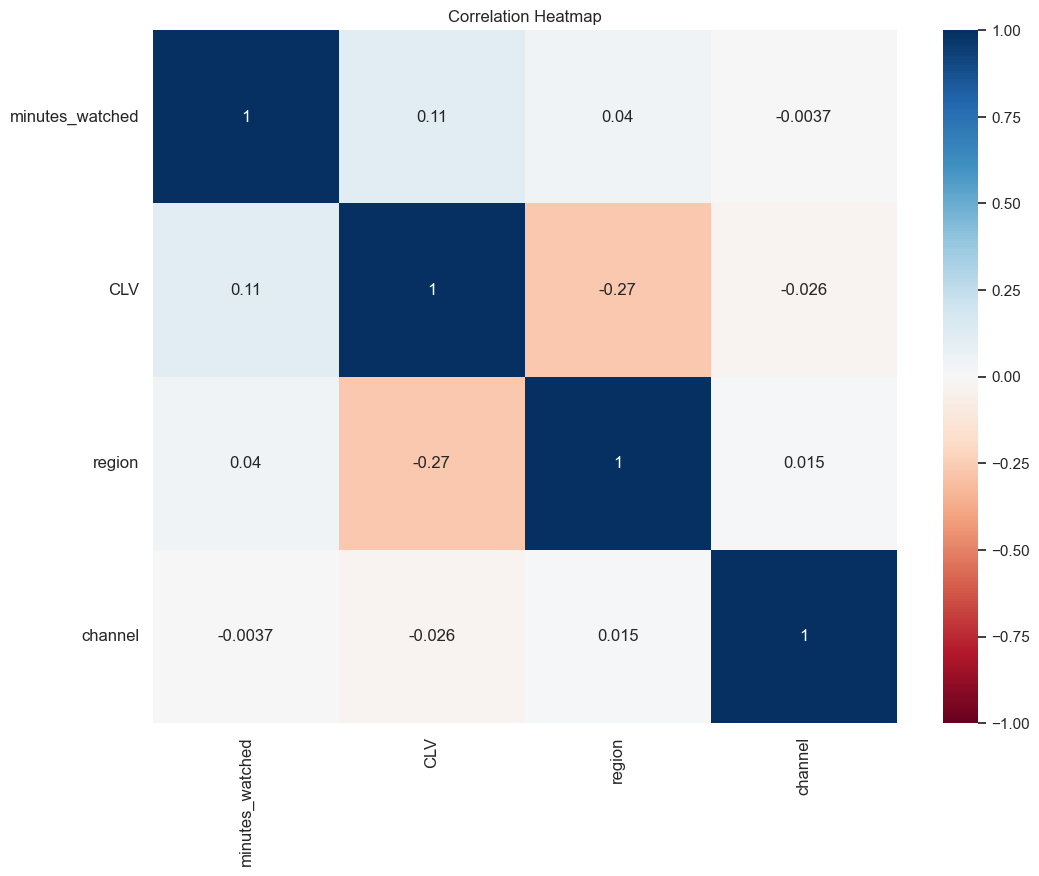

In [10]:
plt.figure(figsize = (12, 9))
s = sns.heatmap(df_segmentation.corr(),
               annot = True, 
               cmap = 'RdBu',
               vmin = -1, 
               vmax = 1)
s.set_yticklabels(s.get_yticklabels(), rotation = 0, fontsize = 12)
s.set_xticklabels(s.get_xticklabels(), rotation = 90, fontsize = 12)
plt.title('Correlation Heatmap')
plt.savefig('corr.png')
plt.show()

### ${\textbf{Visualize Raw Data}}$

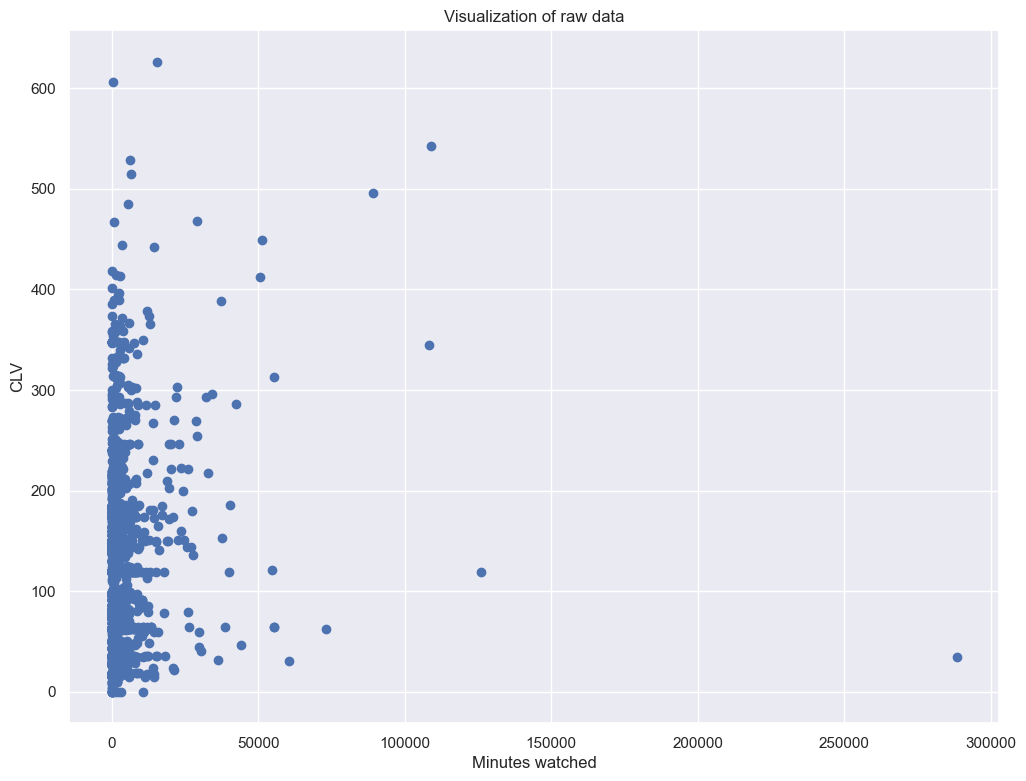

In [11]:
# Setting the size of the plot
plt.figure(figsize = (12, 9))

# Plotting a scatter plot using the first and second columns of the dataframe `df_segmentation`
plt.scatter(df_segmentation.iloc[:, 0], df_segmentation.iloc[:, 1])

# Labeling the x-axis as 'Minutes watched'
plt.xlabel('Minutes watched')

# Labeling the y-axis as 'CLV' (Customer Lifetime Value)
plt.ylabel('CLV')

# Providing a title for the plot
plt.title('Visualization of raw data')

# Saving the plot as a PNG image named 'scatter.png'
plt.savefig("scatter.png")

# Displaying the plot
plt.show()

### ${\textbf{Create Dummy Variables}}$

In [12]:
# create a list of the channels of acquisition variable
df_heard_from = df_segmentation['channel'] 

In [13]:
# create a list of the channels of the country variable
df_countries = df_segmentation['region'] 

In [14]:
# Get dummy variables for each unique value in 'channel'
df_dummies = pd.get_dummies(df['channel'].apply(pd.Series).stack())

# Use groupby on index and then sum the results
df_dummies = df_dummies.groupby(level=0).sum()

# Join the dummy variables to original dataframe
df = df.join(df_dummies)

In [15]:
# identical dummies for the channel of aquisition
segment_dummies = pd.get_dummies(df_heard_from, prefix = 'channel', prefix_sep = '_')
df_segmentation = pd.concat([df_segmentation, segment_dummies], axis = 1)

#df_pa = df_purchase_predictors

In [16]:
# Creating dummy variables for the `df_countries` dataframe. 
# Each column in `df_countries` will be prefixed with 'country_region_' in the new columns.
segment_dummies_2 = pd.get_dummies(df_countries, prefix = 'country_region', prefix_sep = '_')

# Appending the created dummy columns from `segment_dummies_2` to the `df_segmentation` dataframe.
df_segmentation = pd.concat([df_segmentation, segment_dummies_2], axis = 1)

In [17]:
# drop the channel variable as it is non-numerical and we'll not be able to perform the segmentation
df_segmentation = df_segmentation.drop(["channel"], axis = 1)

In [18]:
df_segmentation

,minutes_watched,CLV,region,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,country_region_0,country_region_1,country_region_2
0,3197.0,205.42,2,False,False,False,True,False,False,False,False,False,False,True
1,63.0,149.99,0,True,False,False,False,False,False,False,False,True,False,False
2,605.0,119.00,2,False,True,False,False,False,False,False,False,False,False,True
3,20.0,240.00,2,False,False,False,True,False,False,False,False,False,False,True
4,245.0,184.36,1,False,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3829,11.0,79.00,0,False,False,True,False,False,False,False,False,True,False,False
3830,28.0,79.00,0,False,True,False,False,False,False,False,False,True,False,False
3831,57.0,36.00,2,False,True,False,False,False,False,False,False,False,False,True
3832,44.0,36.00,2,True,False,False,False,False,False,False,False,False,False,True


In [19]:
# rename the columns after adding the dummie variables
df_segmentation = df_segmentation.rename(columns = {'channel_1':'Google', 'channel_2':'Facebook', 'channel_3':'YouTube','channel_4':'LinkedIn', 
                                                    'channel_5':'Twitter', 'channel_6':'Instagram', 'channel_7':'Friend', 'channel_8':'Other',
                                                    'country_region_0':'Region_0','country_region_1':'Region_1','country_region_2':'Region_2'})

In [20]:
df_segmentation

,minutes_watched,CLV,region,Google,Facebook,YouTube,LinkedIn,Twitter,Instagram,Friend,Other,Region_0,Region_1,Region_2
0,3197.0,205.42,2,False,False,False,True,False,False,False,False,False,False,True
1,63.0,149.99,0,True,False,False,False,False,False,False,False,True,False,False
2,605.0,119.00,2,False,True,False,False,False,False,False,False,False,False,True
3,20.0,240.00,2,False,False,False,True,False,False,False,False,False,False,True
4,245.0,184.36,1,False,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3829,11.0,79.00,0,False,False,True,False,False,False,False,False,True,False,False
3830,28.0,79.00,0,False,True,False,False,False,False,False,False,True,False,False
3831,57.0,36.00,2,False,True,False,False,False,False,False,False,False,False,True
3832,44.0,36.00,2,True,False,False,False,False,False,False,False,False,False,True


## ${\textbf{Model Implementation}}$

### ${\textbf{Standardization}}$

In [21]:
# Initializing a StandardScaler object to standardize the features.
scaler = StandardScaler()

# Standardizing the data in the 'df_segmentation' dataframe.
# This means transforming the data so that it has a mean of 0 and a standard deviation of 1 for each feature.
segmentation_std = scaler.fit_transform(df_segmentation)

In [22]:
# Performing hierarchical clustering on the standardized data using the 'ward' method.
# The 'ward' method minimizes the sum of squared differences within all clusters.
hier_clust = linkage(segmentation_std, method = 'ward')

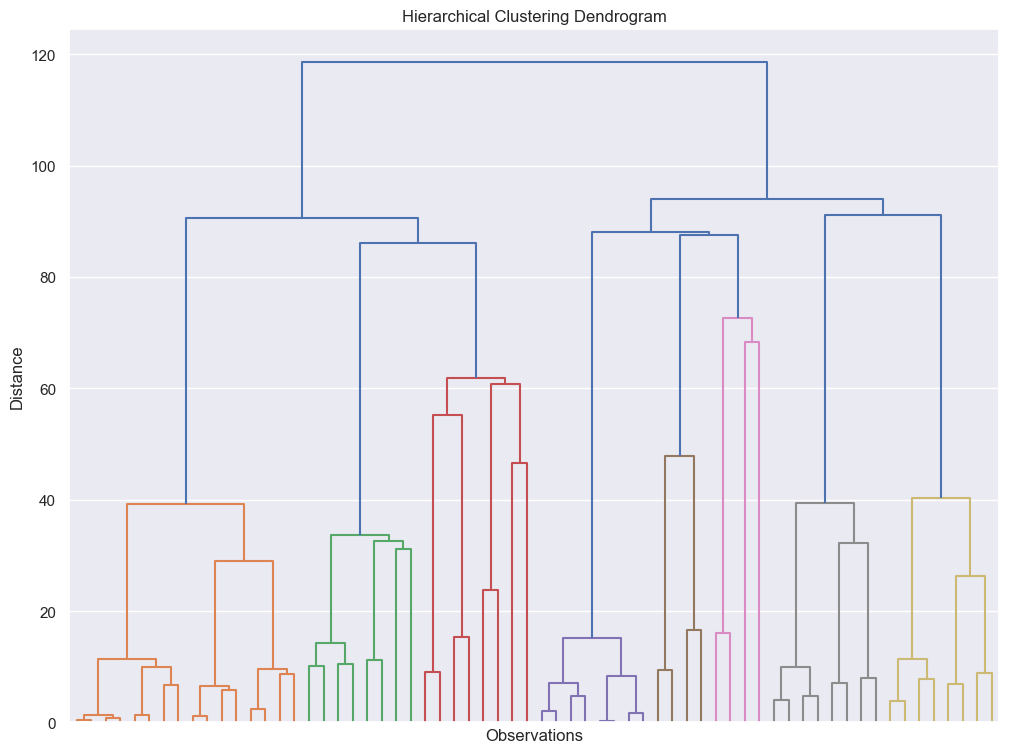

In [23]:
# Setting the figure size for the plot.
plt.figure(figsize = (12,9))

# Setting the title of the dendrogram.
plt.title('Hierarchical Clustering Dendrogram')

# Labeling the x-axis as 'Observations'.
plt.xlabel('Observations')

# Labeling the y-axis as 'Distance'.
plt.ylabel('Distance')

# Creating the dendrogram for the hierarchical clustering result.
# We're truncating the dendrogram to show only the last 5 merged clusters.
# Leaf counts and labels are not displayed.
dendrogram(hier_clust,
           truncate_mode = 'level',
           p = 5,
           show_leaf_counts = False,
           no_labels = True)

# Saving the dendrogram plot as a PNG image named 'hierarchical.png'.
plt.savefig('hierarchical.png')

# Displaying the dendrogram.
plt.show()

### ${\textbf{K-means Clustering}}$

In [24]:
# Initializing an empty list to store the Within-Cluster-Sum-of-Squares (WCSS) for different cluster numbers.
wcss = []

# Looping through numbers 1 to 10 to evaluate the optimal number of clusters for k-means clustering.
for i in range(1,11):
    # Initializing the KMeans algorithm with the current number of clusters (i).
    # Using the 'k-means++' method to initialize the centroids which tends to speed up convergence.
    # Setting a random state for reproducibility.
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    
    # Fitting the standardized data to the KMeans algorithm.
    kmeans.fit(segmentation_std)
    
    # Appending the WCSS value (inertia_) of the current clustering to the wcss list.
    wcss.append(kmeans.inertia_)

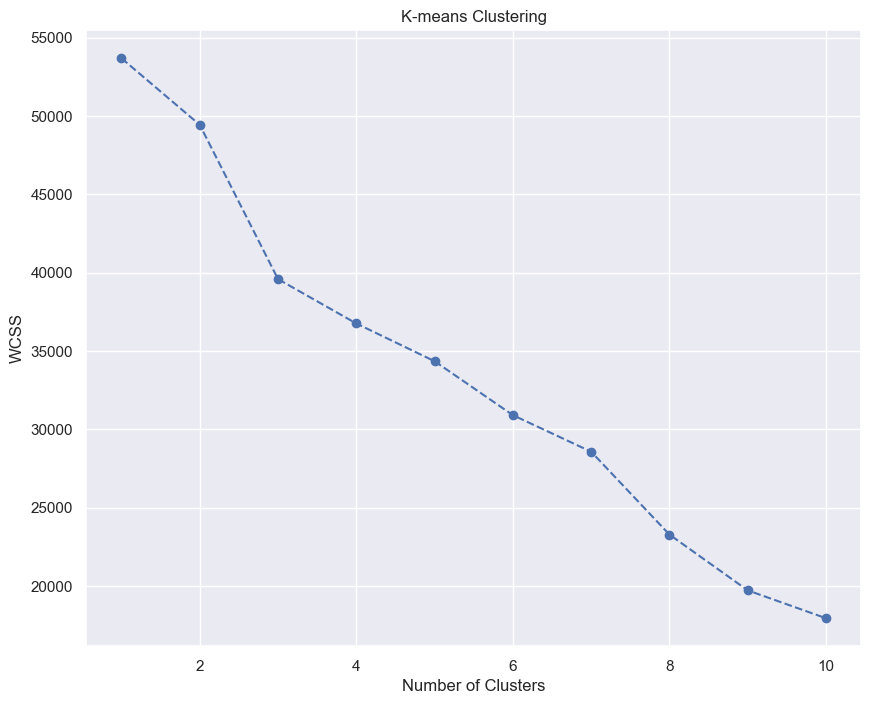

In [25]:


# Setting the figure size for the plot.
plt.figure(figsize = (10,8))

# Plotting the WCSS values against the number of clusters. 
# This is commonly called the Elbow Method, as the elbow point (bend in the line) represents an optimal number of clusters.
plt.plot(range(1, 11), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')

# Saving the Elbow Method plot as a PNG image named 'line_chart.png'.
plt.savefig('line_chart.png')

# Displaying the plot.
plt.show()

In [26]:
# the KMeans algorithm is initialized here with 8 clusters.
kmeans = KMeans(n_clusters = 8, init = 'k-means++', random_state = 42)

In [27]:
# Fitting the standardized data to the KMeans algorithm with 8 clusters.
kmeans.fit(segmentation_std)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## ${\textbf{Model Interpretation and Results}}$

In [28]:
# Creating a copy of the original 'df_segmentation' dataframe to avoid modifying it directly.
df_segm_kmeans = df_segmentation.copy()

# Assigning the cluster labels generated by k-means to a new column named 'Segment' in the copied dataframe.
df_segm_kmeans['Segment'] = kmeans.labels_

In [29]:
pd.set_option('display.max_columns', 500)

In [30]:
df_segm_analysis = df_segm_kmeans.groupby(['Segment']).mean()
df_segm_analysis


# Grouping the dataframe by the 'Segment' column and calculating the mean for each segment.
# This provides a profile for each cluster based on the mean values of the original features.
df_segm_analysis = df_segm_kmeans.groupby(['Segment']).mean()

# Displaying the segmented analysis (this line is more relevant in an interactive environment like Jupyter Notebook).
df_segm_analysis

,minutes_watched,CLV,region,Google,Facebook,YouTube,LinkedIn,Twitter,Instagram,Friend,Other,Region_0,Region_1,Region_2
Segment,,,,,,,,,,,,,,
0,2767.643791,108.260359,1.323529,0.000000,1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.287582,0.101307,0.611111
1,1539.152607,136.329469,0.000000,0.248341,0.0,0.432227,0.179147,0.0,0.0,0.0,0.140284,1.000000,0.000000,0.000000
2,1763.190889,100.376616,1.848156,0.000000,0.0,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.151844,0.848156
3,1800.537897,111.313594,1.801956,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.198044,0.801956
4,2486.479434,118.394974,1.785347,0.000000,0.0,0.820051,0.000000,0.0,0.0,0.0,0.179949,0.000000,0.214653,0.785347
5,2006.190377,113.654038,1.372385,0.000000,0.0,0.000000,0.000000,0.0,0.0,1.0,0.000000,0.257322,0.112971,0.629707
6,985.327586,93.151552,1.603448,0.000000,0.0,0.000000,0.000000,1.0,0.0,0.0,0.000000,0.172414,0.051724,0.775862
7,1299.332180,115.180277,1.186851,0.000000,0.0,0.000000,0.000000,0.0,1.0,0.0,0.000000,0.311419,0.190311,0.498270


In [31]:
df_segm_analysis['N Obs'] = df_segm_kmeans[['Segment','Region_0']].groupby(['Segment']).count()
df_segm_analysis['Prop Obs'] = df_segm_analysis['N Obs'] / df_segm_analysis['N Obs'].sum()


# Counting the number of observations in each segment.
# This is done by grouping by 'Segment' and counting the occurrences.
# 'Region_0' is used arbitrarily to count, as it exists in each segment.
df_segm_analysis['N Obs'] = df_segm_kmeans[['Segment','Region_0']].groupby(['Segment']).count()

# Calculating the proportion of observations in each segment.
# This is done by dividing the number of observations in a segment by the total number of observations.
df_segm_analysis['Prop Obs'] = df_segm_analysis['N Obs'] / df_segm_analysis['N Obs'].sum()

In [32]:
# Rounding the dataframe values to 2 decimal places for cleaner presentation.
df_segm_analysis.round(2)

,minutes_watched,CLV,region,Google,Facebook,YouTube,LinkedIn,Twitter,Instagram,Friend,Other,Region_0,Region_1,Region_2,N Obs,Prop Obs
Segment,,,,,,,,,,,,,,,,
0,2767.64,108.26,1.32,0.00,1.0,0.00,0.00,0.0,0.0,0.0,0.00,0.29,0.10,0.61,306,0.08
1,1539.15,136.33,0.00,0.25,0.0,0.43,0.18,0.0,0.0,0.0,0.14,1.00,0.00,0.00,1055,0.28
2,1763.19,100.38,1.85,0.00,0.0,0.00,1.00,0.0,0.0,0.0,0.00,0.00,0.15,0.85,461,0.12
3,1800.54,111.31,1.80,1.00,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.20,0.80,409,0.11
4,2486.48,118.39,1.79,0.00,0.0,0.82,0.00,0.0,0.0,0.0,0.18,0.00,0.21,0.79,778,0.20
5,2006.19,113.65,1.37,0.00,0.0,0.00,0.00,0.0,0.0,1.0,0.00,0.26,0.11,0.63,478,0.12
6,985.33,93.15,1.60,0.00,0.0,0.00,0.00,1.0,0.0,0.0,0.00,0.17,0.05,0.78,58,0.02
7,1299.33,115.18,1.19,0.00,0.0,0.00,0.00,0.0,1.0,0.0,0.00,0.31,0.19,0.50,289,0.08


In [33]:
# Renaming the index labels (which are segment numbers) with more descriptive names.
# This provides a more interpretable profile for each cluster.
df_segm_analysis.rename({0:'Instagram Explorers',
                         1:'LinkedIn Networkers',
                         2:'Friends\' Influence',
                         3:'Google-YouTube Mix',
                         4:'Anglo-Saxon Multi-Channel', 
                         5:'European Multi-Channel',
                         6:'Twitter Devotees',
                         7:'Facebook Followers', 
                        })


,minutes_watched,CLV,region,Google,Facebook,YouTube,LinkedIn,Twitter,Instagram,Friend,Other,Region_0,Region_1,Region_2,N Obs,Prop Obs
Segment,,,,,,,,,,,,,,,,
Instagram Explorers,2767.643791,108.260359,1.323529,0.000000,1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.287582,0.101307,0.611111,306,0.079812
LinkedIn Networkers,1539.152607,136.329469,0.000000,0.248341,0.0,0.432227,0.179147,0.0,0.0,0.0,0.140284,1.000000,0.000000,0.000000,1055,0.275170
Friends' Influence,1763.190889,100.376616,1.848156,0.000000,0.0,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.151844,0.848156,461,0.120240
Google-YouTube Mix,1800.537897,111.313594,1.801956,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.198044,0.801956,409,0.106677
Anglo-Saxon Multi-Channel,2486.479434,118.394974,1.785347,0.000000,0.0,0.820051,0.000000,0.0,0.0,0.0,0.179949,0.000000,0.214653,0.785347,778,0.202921
European Multi-Channel,2006.190377,113.654038,1.372385,0.000000,0.0,0.000000,0.000000,0.0,0.0,1.0,0.000000,0.257322,0.112971,0.629707,478,0.124674
Twitter Devotees,985.327586,93.151552,1.603448,0.000000,0.0,0.000000,0.000000,1.0,0.0,0.0,0.000000,0.172414,0.051724,0.775862,58,0.015128
Facebook Followers,1299.332180,115.180277,1.186851,0.000000,0.0,0.000000,0.000000,0.0,1.0,0.0,0.000000,0.311419,0.190311,0.498270,289,0.075378


In [34]:
# Mapping the cluster numbers (Segment) to more human-readable labels using a dictionary.
# This helps in interpreting the clusters in plots and other visualizations.
df_segm_kmeans['Labels'] = df_segm_kmeans['Segment'].map({0:'Instagram Explorers',
                         1:'LinkedIn Networkers',
                         2:'Friends\' Influence',
                         3:'Google-YouTube Mix',
                         4:'Anglo-Saxon Multi-Channel', 
                         5:'European Multi-Channel',
                         6:'Twitter Devotees',
                         7:'Facebook Followers', 
                        })

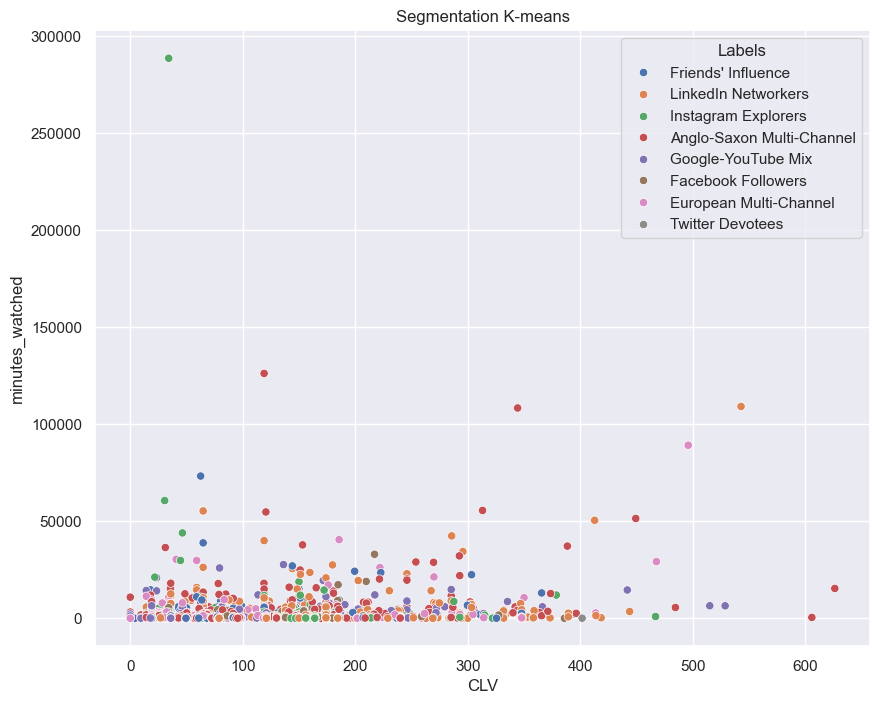

In [35]:
# Defining the x-axis data as 'total_payments' from the dataframe.
x_axis = df_segm_kmeans['CLV']

# Defining the y-axis data as 'minutes_watched' from the dataframe
y_axis = df_segm_kmeans['minutes_watched']

# Setting the figure size for the scatter plot.
plt.figure(figsize = (10, 8))

# Creating a scatter plot using seaborn.
# The 'hue' parameter colors the points based on the 'Labels' column, allowing for distinction between clusters.
sns.scatterplot(x = x_axis, y = y_axis, hue = df_segm_kmeans['Labels'])

# Setting the title of the scatter plot.
plt.title('Segmentation K-means')

# Displaying the scatter plot.
plt.show()

In [36]:
from sklearn.decomposition import PCA

# Ghadi nkhdmo b 'segmentation_std' li derti liha StandardScaler 9bel
pca = PCA(n_components=2)
pca_results = pca.fit_transform(segmentation_std)

# Ndiroha f DataFrame bach n-khdmo biha hsen
df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])

In [38]:
# 1. Creer DataFrame jdid fih l-components dyal PCA
df_segm_pca_kmeans_viz = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])

# 2. Zid lihom l-labels li 7sebti
df_segm_pca_kmeans_viz['DBSCAN Labels'] = db_labels
df_segm_pca_kmeans_viz['GMM Labels'] = gmm_labels

# 3. (Ikhtiyari) Zid 7ta l-labels dyal K-Means l-9dam bach t-compare
# df_segm_pca_kmeans_viz['KMeans Labels'] = df_segm_kmeans['Labels']

# Chouf l-natija
df_segm_pca_kmeans_viz.head()

,PC1,PC2,DBSCAN Labels,GMM Labels
0,1.378531,-0.264312,0,2
1,-2.151784,-1.248876,1,1
2,1.648744,-0.263123,0,2
3,1.253327,-0.162082,0,2
4,-0.538023,1.026379,0,3


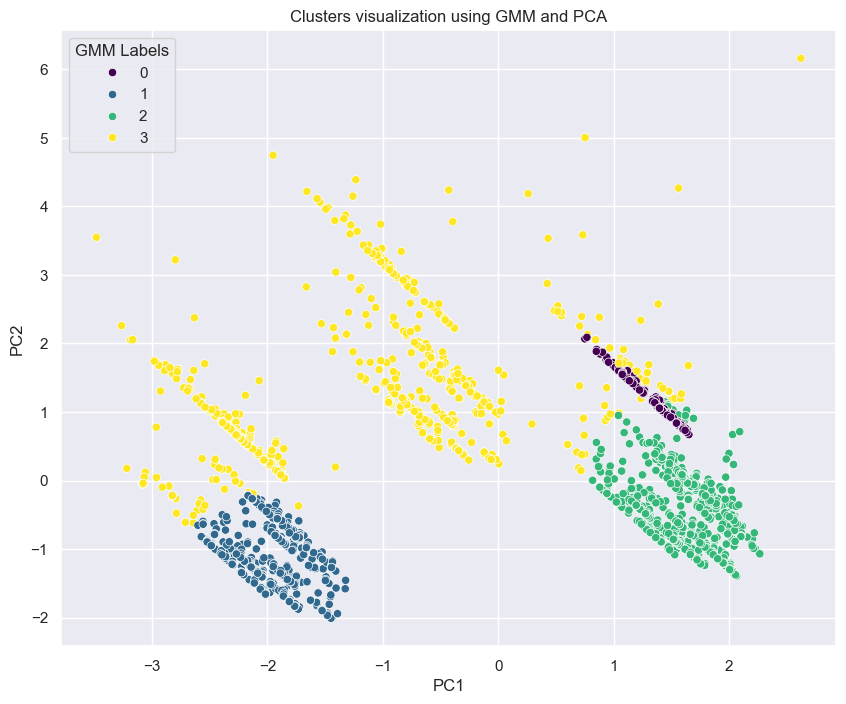

In [39]:
plt.figure(figsize = (10, 8))
sns.scatterplot(x = df_segm_pca_kmeans_viz['PC1'], 
                y = df_segm_pca_kmeans_viz['PC2'], 
                hue = df_segm_pca_kmeans_viz['GMM Labels'], 
                palette = 'viridis')
plt.title('Clusters visualization using GMM and PCA')
plt.show()

In [40]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# --- DBSCAN ---
dbscan = DBSCAN(eps=0.5, min_samples=5) # khass t-tester 'eps' 3la hsab data dyalk
db_labels = dbscan.fit_predict(df_pca)

# --- GMM ---
gmm = GaussianMixture(n_components=4) # nfs l-3adad dyal K-means
gmm_labels = gmm.fit_predict(df_pca)

# Zid l-natayij f DataFrame dyalk
df_segm_pca_kmeans_viz['DBSCAN Labels'] = db_labels
df_segm_pca_kmeans_viz['GMM Labels'] = gmm_labels

In [41]:
# N-zido l-labels jdad l-DataFrame l-asli (df)
df['PCA_PC1'] = df_pca['PC1']
df['PCA_PC2'] = df_pca['PC2']
df['GMM_Segment'] = gmm_labels

# Export to CSV
df.to_csv('segmented_customers_final.csv', index=False)
print("File 'segmented_customers_final.csv' is ready for Power BI!")

File 'segmented_customers_final.csv' is ready for Power BI!
